# Dementia Classifier — Neural Network Baseline

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid")
np.set_printoptions(precision=4, suppress=True)

CHALLENGE_ROOT = Path.cwd().resolve()
if CHALLENGE_ROOT.name == "notebooks":
    CHALLENGE_ROOT = CHALLENGE_ROOT.parent
    
DATA_RAW  = Path("/kaggle/input/datasets/shashwatwork/dementia-prediction-dataset")
RESULTS_DIR = CHALLENGE_ROOT / "results"

SPLIT_SEED = 42
torch.manual_seed(SPLIT_SEED)
np.random.seed(SPLIT_SEED)

TRAIN_SIZE = 0.6
VAL_SIZE   = 0.2   # remaining 0.2 → test

## Data

In [2]:
SUBJECT_ID_CANDIDATES = (
    "subject_id", "Subject ID", "ID", "MRI ID", "MRI_ID", "Patient ID",
)
GROUP_CANDIDATES = ("Group", "group", "Dementia", "dementia", "Target", "target")
FEATURE_CANDIDATES = (
    "Age", "EDUC", "SES", "MMSE", "CDR", "eTIV", "nWBV", "ASF", "MR Delay", "M/F", "Hand",
)


def _find_csv(raw_dir: Path) -> Path | None:
    if not raw_dir.is_dir():
        return None
    for name in ("oasis.csv", "dementia.csv", "data.csv", "dataset.csv"):
        p = raw_dir / name
        if p.is_file():
            return p
    csvs = sorted(raw_dir.glob("*.csv"))
    return csvs[0] if csvs else None


def _pick_column(df: pd.DataFrame, candidates: tuple[str, ...]) -> str | None:
    lower_map = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        if cand.lower().strip() in lower_map:
            return lower_map[cand.lower().strip()]
    return None


def _encode_group(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip().str.lower()
    demented    = s.str.contains("dement", na=False) & ~s.str.contains("nondement", na=False)
    nondemented = s.str.contains("nondement", na=False)
    label = pd.Series(np.nan, index=series.index, dtype=float)
    label[demented]    = 1.0
    label[nondemented] = 0.0
    return label


def _synthetic_demo(n_subjects: int = 120, seed: int = 42) -> pd.DataFrame:
    rng   = np.random.default_rng(seed)
    n_dem = n_subjects // 2
    y     = np.array([1] * n_dem + [0] * (n_subjects - n_dem))
    rng.shuffle(y)
    age  = rng.normal(76, 7, n_subjects);  age[y == 1]  += 2
    mmse = rng.normal(27, 3, n_subjects);  mmse[y == 1] -= 5
    return pd.DataFrame({
        "subject_id": [f"SUBJ_{i:03d}" for i in range(n_subjects)],
        "y":    y.astype(float),
        "Age":  age,
        "EDUC": rng.integers(8, 20, n_subjects).astype(float),
        "MMSE": mmse,
        "CDR":  np.where(y == 1, rng.choice([0.5, 1.0, 2.0], n_subjects), 0.0),
        "eTIV": rng.normal(1500, 200, n_subjects),
        "nWBV": rng.normal(0.72, 0.08, n_subjects) - 0.05 * y,
        "ASF":  rng.normal(1.2, 0.15, n_subjects),
        "SES":  rng.integers(1, 5, n_subjects).astype(float),
        "MR Delay": rng.exponential(0.5, n_subjects),
    })


def load_raw_frame(raw_dir: Path | None = None) -> tuple[pd.DataFrame, str]:
    raw_dir  = raw_dir or DATA_RAW
    csv_path = _find_csv(raw_dir)
    if csv_path is None:
        return _synthetic_demo(), "synthetic:demo (place Kaggle CSV in data/raw/)"

    df         = pd.read_csv(csv_path)
    subject_col = _pick_column(df, SUBJECT_ID_CANDIDATES) or df.columns[0]
    group_col  = _pick_column(df, GROUP_CANDIDATES)
    if group_col is None:
        raise ValueError(f"No Group column in {csv_path.name}. Columns: {list(df.columns)}")

    df = df.assign(subject_id=df[subject_col].astype(str), y=_encode_group(df[group_col]))
    df = df.dropna(subset=["y"])
    df = df[df["y"].isin([0.0, 1.0])]

    # 🚨 FIX: Safely map categorical string text to numerical values before coercion loop
    mf_col = _pick_column(df, ("M/F",))
    if mf_col:
        df[mf_col] = df[mf_col].astype(str).str.strip().str.upper().map({"M": 1.0, "F": 0.0})
        
    hand_col = _pick_column(df, ("Hand",))
    if hand_col:
        df[hand_col] = df[hand_col].astype(str).str.strip().str.upper().map({"R": 1.0, "L": 0.0})

    feature_cols = []
    for cand in FEATURE_CANDIDATES:
        col = _pick_column(df, (cand,))
        if col and col not in feature_cols:
            feature_cols.append(col)
    if not feature_cols:
        feature_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != "y"]

    # Keeping this commented out lets us look at all longitudinal rows safely!
    # df  = df.sort_index().groupby("subject_id", as_index=False).first()
    
    out = df[["subject_id", "y"] + feature_cols].copy()
    for c in feature_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out.dropna(), f"file:{csv_path.name}"


df, DATA_SOURCE = load_raw_frame()
print("Data source:", DATA_SOURCE)
display(df.head())
print(f"Subjects: {len(df)} | Demented fraction: {df['y'].mean():.3f}")

feature_names = [c for c in df.columns if c not in ("subject_id", "y")]
X = df[feature_names].to_numpy(dtype=float)
y = df["y"].to_numpy(dtype=int)

Data source: file:dementia_dataset.csv


,subject_id,y,Age,EDUC,SES,MMSE,CDR,eTIV,nWBV,ASF,MR Delay,M/F,Hand
0,OAS2_0001,0.0,87,14,2.0,27.0,0.0,1987,0.696,0.883,0,1.0,1.0
1,OAS2_0001,0.0,88,14,2.0,30.0,0.0,2004,0.681,0.876,457,1.0,1.0
5,OAS2_0004,0.0,88,18,3.0,28.0,0.0,1215,0.710,1.444,0,0.0,1.0
6,OAS2_0004,0.0,90,18,3.0,27.0,0.0,1200,0.718,1.462,538,0.0,1.0
7,OAS2_0005,0.0,80,12,4.0,28.0,0.0,1689,0.712,1.039,0,1.0,1.0


Subjects: 317 | Demented fraction: 0.401


## Preprocessing & Split

In [3]:
test_size = 1.0 - TRAIN_SIZE - VAL_SIZE

subject_data = df.groupby("subject_id")["y"].first()
unique_subjects = subject_data.index.to_numpy()
subject_labels = subject_data.to_numpy().astype(int)

train_subs, temp_subs, y_train_subs, y_temp_subs = train_test_split(
    unique_subjects,
    subject_labels,
    test_size=(1.0 - TRAIN_SIZE),
    stratify=subject_labels,
    random_state=SPLIT_SEED
)

val_subs, test_subs = train_test_split(
    temp_subs,
    test_size=test_size / (VAL_SIZE + test_size),
    stratify=y_temp_subs,
    random_state=SPLIT_SEED + 1,
)

train_mask = df["subject_id"].isin(train_subs).to_numpy()
val_mask   = df["subject_id"].isin(val_subs).to_numpy()
test_mask  = df["subject_id"].isin(test_subs).to_numpy()

X_train_raw = X[train_mask]
X_val_raw   = X[val_mask]
X_test_raw  = X[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

print(f"Rows - Train / val / test: {len(y_train)} / {len(y_val)} / {len(y_test)}")
print(f"Unique Patients - Train: {len(train_subs)} | Val: {len(val_subs)} | Test: {len(test_subs)}")

scaler      = StandardScaler()
X_train_s   = scaler.fit_transform(X_train_raw)
X_val_s     = scaler.transform(X_val_raw)
X_test_s    = scaler.transform(X_test_raw)

print(f"Input dimension: {X_train_s.shape[1]} features")

Rows - Train / val / test: 188 / 71 / 58
Unique Patients - Train: 76 | Val: 26 | Test: 26
Input dimension: 11 features


## Neural Network Definition

Edit this cell to change the architecture.  
Key knobs:
- **`HIDDEN_SIZES`** — list of hidden layer widths, e.g. `[64, 32]`
- **`DROPOUT`** — dropout probability (set to `0.0` to disable)
- **`ACTIVATION`** — swap `nn.ReLU` for `nn.Tanh`, `nn.GELU`, etc.
- **`LR`** / **`EPOCHS`** / **`BATCH_SIZE`** — training hyperparameters

In [4]:
HIDDEN_SIZES = [16, 8]   # one entry per hidden layer, e.g. [128, 64, 32]
DROPOUT      = 0.3        # dropout probability; set to 0.0 to remove
ACTIVATION   = nn.ReLU   # try nn.Tanh, nn.GELU, nn.SiLU, …

LR         = 1e-3
EPOCHS     = 100
BATCH_SIZE = 32


class DementiaNet(nn.Module):
    """
    Fully-connected binary classifier.
    The architecture is driven entirely by HIDDEN_SIZES, DROPOUT, and ACTIVATION
    defined above — no need to touch this class.
    """

    def __init__(self, input_dim: int):
        super().__init__()
        layers: list[nn.Module] = []
        in_dim = input_dim

        for out_dim in HIDDEN_SIZES:
            layers.append(nn.Linear(in_dim, out_dim))
            layers.append(nn.BatchNorm1d(out_dim))
            layers.append(ACTIVATION())
            if DROPOUT > 0.0:
                layers.append(nn.Dropout(DROPOUT))
            in_dim = out_dim

        layers.append(nn.Linear(in_dim, 1))   # binary output logit
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)


INPUT_DIM = X_train_s.shape[1]
model     = DementiaNet(INPUT_DIM)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

DementiaNet(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=8, out_features=1, bias=True)
  )
)

Total trainable parameters: 385


## Training

In [5]:
def make_loader(X: np.ndarray, y: np.ndarray, shuffle: bool) -> DataLoader:
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32),
    )
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle)


train_loader = make_loader(X_train_s, y_train, shuffle=True)
val_loader   = make_loader(X_val_s,   y_val,   shuffle=False)

# ── Loss & optimiser ──────────────────────────────────────────────────────────
# Compute positive-class weight to handle class imbalance
pos_weight = torch.tensor(
    [(y_train == 0).sum() / max((y_train == 1).sum(), 1)], dtype=torch.float32
)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)


def run_epoch(loader: DataLoader, train: bool) -> tuple[float, float]:
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            preds       = (torch.sigmoid(logits) >= 0.5).long()
            correct    += (preds == y_batch.long()).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


# ── Training loop ─────────────────────────────────────────────────────────────
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{EPOCHS} | "
              f"train loss {tr_loss:.4f}  acc {tr_acc:.3f} | "
              f"val loss {vl_loss:.4f}  acc {vl_acc:.3f}")

Epoch    1/100 | train loss 0.8801  acc 0.559 | val loss 0.8479  acc 0.563
Epoch   10/100 | train loss 0.7021  acc 0.782 | val loss 0.7076  acc 0.831
Epoch   20/100 | train loss 0.5768  acc 0.862 | val loss 0.5641  acc 0.859
Epoch   30/100 | train loss 0.4399  acc 0.941 | val loss 0.4476  acc 0.901
Epoch   40/100 | train loss 0.3233  acc 0.947 | val loss 0.3407  acc 0.915
Epoch   50/100 | train loss 0.2926  acc 0.963 | val loss 0.2381  acc 0.986
Epoch   60/100 | train loss 0.1904  acc 0.968 | val loss 0.1765  acc 0.986
Epoch   70/100 | train loss 0.1902  acc 0.952 | val loss 0.1339  acc 0.986
Epoch   80/100 | train loss 0.1780  acc 0.973 | val loss 0.1083  acc 0.986
Epoch   90/100 | train loss 0.1251  acc 0.995 | val loss 0.0942  acc 0.986
Epoch  100/100 | train loss 0.1107  acc 0.984 | val loss 0.0812  acc 0.986


## Learning Curves

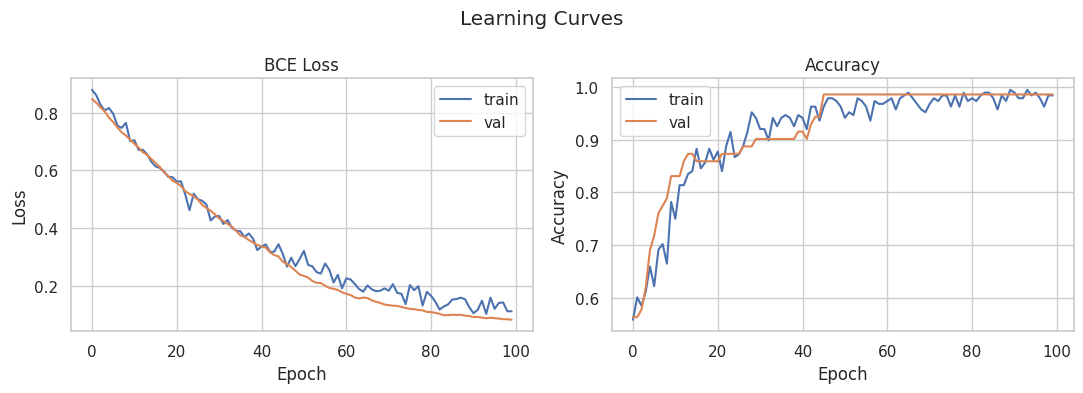

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"],   label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("BCE Loss"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"],   label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.suptitle("Learning Curves")
plt.tight_layout()
plt.show()

## Results

In [7]:
def predict(X_np: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Returns (binary predictions, probability scores)."""
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_np, dtype=torch.float32))
        probs  = torch.sigmoid(logits).numpy()
    return (probs >= 0.5).astype(int), probs


def metric_row(split: str, y_true: np.ndarray, y_pred: np.ndarray, y_score: np.ndarray) -> dict:
    return {
        "split":    split,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1":       float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc":  float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else None,
    }


# ── Evaluate on all splits ────────────────────────────────────────────────────
splits = {
    "train": (X_train_s, y_train),
    "val":   (X_val_s,   y_val),
    "test":  (X_test_s,  y_test),
}

preds_store = {}
metric_rows = []
for split_name, (X_sp, y_sp) in splits.items():
    y_pred, y_score = predict(X_sp)
    preds_store[split_name] = (y_pred, y_score)
    metric_rows.append(metric_row(split_name, y_sp, y_pred, y_score))

# ── Print table ───────────────────────────────────────────────────────────────
header = f"{'split':<8} {'accuracy':>10} {'F1':>10} {'ROC-AUC':>10}"
print(header)
print("-" * len(header))
for r in metric_rows:
    auc = f"{r['roc_auc']:10.4f}" if r["roc_auc"] is not None else f"{'n/a':>10}"
    print(f"{r['split']:<8} {r['accuracy']:10.4f} {r['f1']:10.4f} {auc}")

split      accuracy         F1    ROC-AUC
-----------------------------------------
train        0.9947     0.9933     1.0000
val          0.9859     0.9836     0.9984
test         1.0000     1.0000     1.0000


## Confusion Matrices

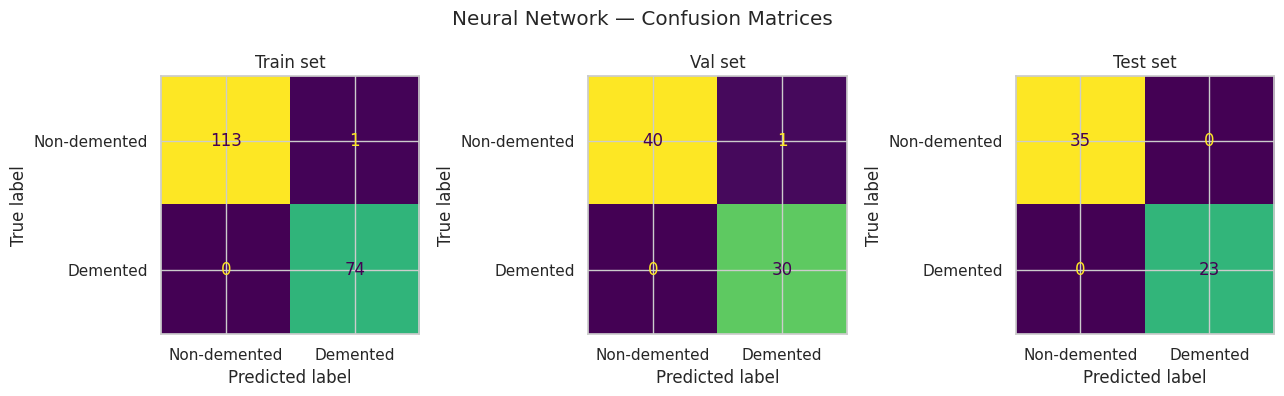

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (split_name, (_, y_sp)) in zip(axes, splits.items()):
    y_pred, _ = preds_store[split_name]
    ConfusionMatrixDisplay.from_predictions(
        y_sp, y_pred,
        display_labels=["Non-demented", "Demented"],
        ax=ax, colorbar=False,
    )
    ax.set_title(f"{split_name.capitalize()} set")

plt.suptitle("Neural Network — Confusion Matrices")
plt.tight_layout()
plt.show()